### Models Selection, Training and Evaluation

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [16]:
df = pd.read_csv("ai_job_replacement_2020_2026_v2.csv")

In [35]:
encoder = LabelEncoder()

# Find categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode them
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

### Feature Selection

In [57]:
X = df.drop([
    "automation_risk_category",
    "automation_risk_percent",
    "ai_replacement_score",
    "ai_disruption_intensity",
    "reskilling_urgency_score"
], axis=1)

y = df["automation_risk_category"]

### Split Training and Testing Data

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (12000, 15)
Testing Size: (3000, 15)


### Logistic Regression

In [59]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)  # Train
lr_pred = lr.predict(X_test)  # Predict
lr_acc = accuracy_score(y_test, lr_pred)  # Accuracy
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.944


c:\Users\Asus\Desktop\freerider_cs451_final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree

In [60]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("\nDecision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.9716666666666667


### Random Forest

In [61]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("\nRandom Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.8426666666666667


In [62]:
# Logistic Regression Report
lr_report = classification_report(y_test, lr_pred, output_dict=True)
lr_df = pd.DataFrame(lr_report).transpose()
print("\nLogistic Regression Classification Report:")
display(lr_df)  # Jupyter-friendly table display

# Decision Tree Report
dt_report = classification_report(y_test, dt_pred, output_dict=True)
dt_df = pd.DataFrame(dt_report).transpose()
print("\nDecision Tree Classification Report:")
display(dt_df)

# Random Forest Report
rf_report = classification_report(y_test, rf_pred, output_dict=True)
rf_df = pd.DataFrame(rf_report).transpose()
print("\nRandom Forest Classification Report:")
display(rf_df)


Logistic Regression Classification Report:


,precision,recall,f1-score,support
0,0.946772,0.926829,0.936695,902.000
1,0.977041,0.953923,0.965343,803.000
2,0.922731,0.949807,0.936073,1295.000
accuracy,0.944000,0.944000,0.944000,0.944
macro avg,0.948848,0.943520,0.946037,3000.000
weighted avg,0.944496,0.944000,0.944095,3000.000



Decision Tree Classification Report:


,precision,recall,f1-score,support
0,0.976718,0.976718,0.976718,902.000000
1,0.975000,0.971357,0.973175,803.000000
2,0.966102,0.968340,0.967219,1295.000000
accuracy,0.971667,0.971667,0.971667,0.971667
macro avg,0.972607,0.972139,0.972371,3000.000000
weighted avg,0.971676,0.971667,0.971670,3000.000000



Random Forest Classification Report:


,precision,recall,f1-score,support
0,0.945455,0.807095,0.870813,902.000000
1,0.947627,0.721046,0.818953,803.000000
2,0.754169,0.942857,0.838023,1295.000000
accuracy,0.842667,0.842667,0.842667,0.842667
macro avg,0.882417,0.823666,0.842597,3000.000000
weighted avg,0.863465,0.842667,0.842778,3000.000000


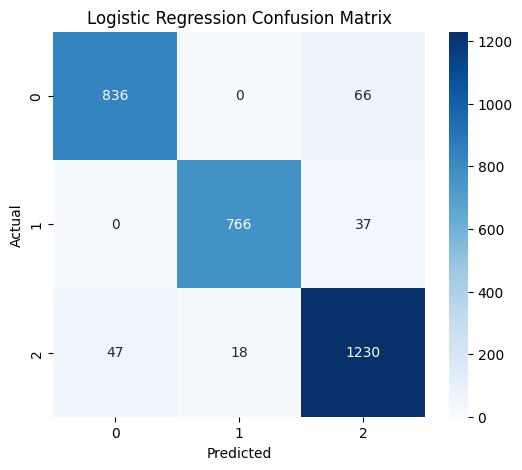

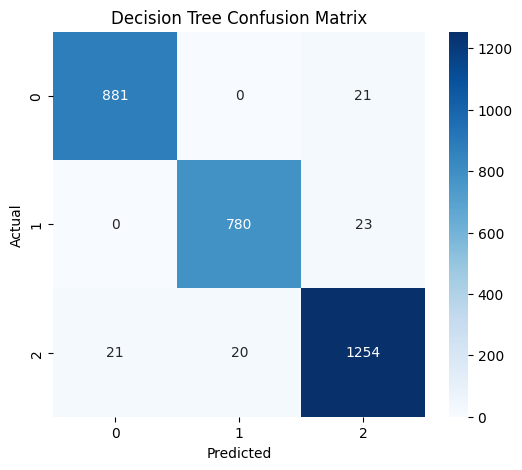

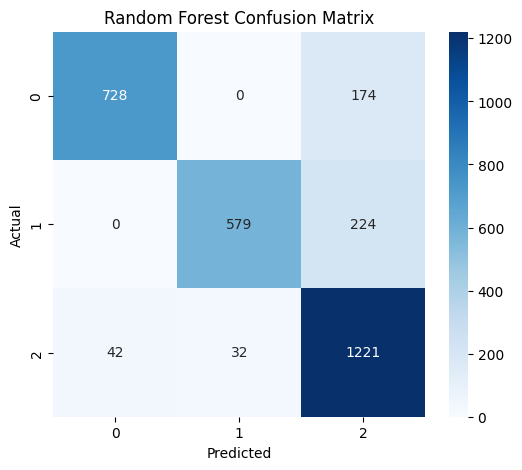

In [51]:
models_preds = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, preds in models_preds.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [52]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [lr_acc, dt_acc, rf_acc]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": scores
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.944000
1        Decision Tree  0.971667
2        Random Forest  0.842667


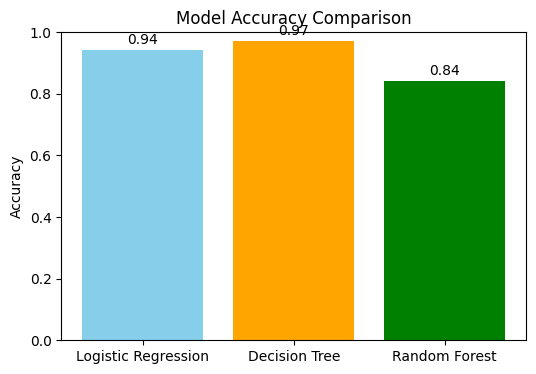

In [53]:
plt.figure(figsize=(6,4))
bars = plt.bar(models, scores, color=['skyblue','orange','green'])
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Add accuracy value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x-position
        height + 0.01,                   # y-position slightly above the bar
        f"{height:.2f}",                 # text with 2 decimal places
        ha='center', va='bottom'         # center horizontally, align bottom vertically
    )

plt.show()

                        Feature  Importance
13    skill_transition_pressure    0.516894
5               skill_gap_index    0.230077
1                      job_role    0.052739
10     remote_feasibility_score    0.022284
11            ai_adoption_level    0.021927
9   skill_demand_growth_percent    0.021448
6             salary_before_usd    0.021360
0                        job_id    0.021319
8         salary_change_percent    0.021154
7              salary_after_usd    0.020355


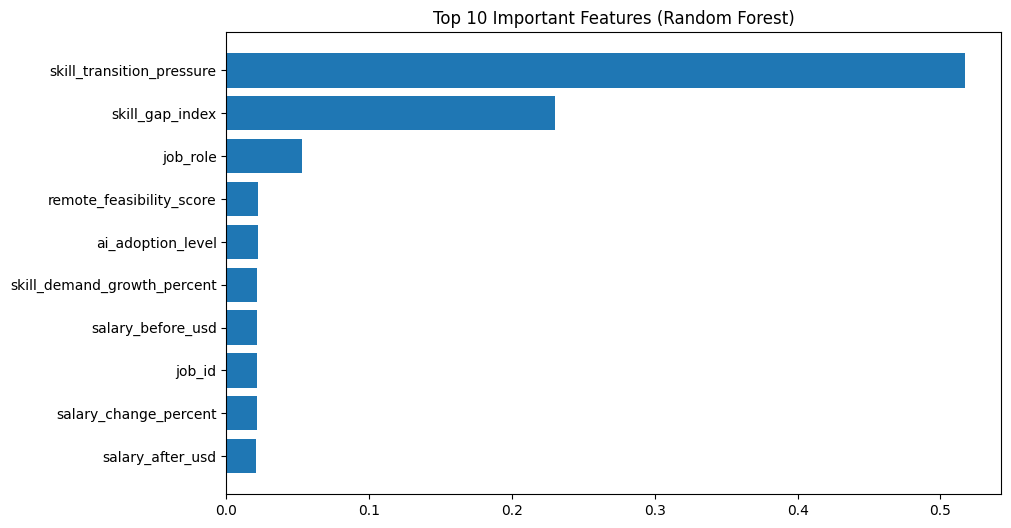

In [54]:
importance = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:10], feature_importance["Importance"][:10])
plt.title("Top 10 Important Features (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [55]:
import joblib

# Save Logistic Regression model
joblib.dump(lr, "logistic_regression_model.pkl")

# Save Decision Tree model
joblib.dump(dt, "decision_tree_model.pkl")

# Save Random Forest model
joblib.dump(rf, "random_forest_model.pkl")

print("All models have been saved successfully!")

All models have been saved successfully!
